In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))  # "Programming Part" auf sys.path

from env import gymnasium_env as drausp_env
import numpy as np

from env.instance_reader import get_instance_data
import matplotlib.pyplot as plt

data_path = Path("../../instances/lion18s/SA01.txt")

In [2]:
DRAUSP_data = get_instance_data(data_path)

K = DRAUSP_data.num_slots
T_d = DRAUSP_data.num_requests
C_k = DRAUSP_data.capacity_vector
instance = DRAUSP_data.instance
request_length = DRAUSP_data.request_length
print(K)
print(T_d)
print(C_k)
print(instance)

4
50
[10, 10, 10, 10]
[[41, 1, 1, 0, 0], [39, 1, 1, 0, 0], [20, 1, 3, 0, 0], [61, 2, 1, 0, 0], [18, 2, 1, 0, 0], [23, 1, 4, 0, 0], [25, 1, 1, 0, 0], [13, 1, 1, 0, 0], [77, 1, 1, 0, 0], [8, 1, 2, 0, 0], [25, 1, 3, 0, 0], [74, 1, 1, 0, 0], [39, 1, 3, 0, 0], [54, 3, 2, 0, 0], [70, 1, 3, 0, 0], [71, 1, 1, 0, 0], [55, 1, 1, 0, 0], [9, 1, 1, 0, 0], [96, 1, 1, 0, 0], [63, 3, 2, 0, 0], [50, 3, 2, 0, 0], [20, 1, 1, 0, 0], [43, 1, 2, 0, 0], [74, 1, 2, 0, 0], [62, 1, 1, 0, 0], [60, 1, 1, 0, 0], [22, 1, 1, 0, 0], [81, 1, 2, 0, 0], [92, 1, 1, 0, 0], [80, 1, 1, 0, 0], [38, 2, 1, 0, 0], [84, 1, 1, 0, 0], [39, 1, 2, 0, 0], [88, 2, 1, 0, 0], [69, 1, 3, 0, 0], [21, 2, 1, 0, 0], [15, 1, 1, 0, 0], [47, 3, 1, 0, 0], [67, 1, 1, 0, 0], [18, 1, 1, 0, 0], [87, 1, 1, 0, 0], [58, 1, 2, 0, 0], [34, 2, 1, 0, 0], [8, 1, 1, 0, 0], [97, 1, 1, 0, 0], [73, 1, 1, 0, 0], [54, 1, 1, 0, 0], [69, 2, 1, 0, 0], [79, 1, 2, 0, 0], [9, 1, 2, 0, 0]]


In [3]:
env = drausp_env.DrauspEnv(K=K, T_d=T_d, C_k=C_k, instance=instance, render_mode="human", fixed_request_length=request_length)

In [4]:
from training.dqn_agent import DQNAgent
from models.lattice_dqn import LatticeDQNNetwork
from models.lattice_dqn_withaction import LatticeDQNNetworkWithAction
agent = DQNAgent(env, QnetworkClass=LatticeDQNNetworkWithAction, reject_bias = 0.75, gamma = 0.98, epsilon_decay_steps=10000)

In [5]:
reward_history, monotonicity_violations, depth_history = agent.train(num_episodes=1000)

  Systematic monotonicity (Episode 1): C_k: 100.0%, t: 61.2%, r: 73.0%, q: 21.0%, mixed: 100.0%
Episode   50/1000  Reward:   421.00  Avg(50):   523.12  Tiefe:   24  Avg-Tiefe(50):   34.6  ε: 0.857
  Systematic monotonicity (Episode 51): C_k: 100.0%, t: 1.0%, r: 88.0%, q: 0.0%, mixed: 100.0%
Episode  100/1000  Reward:   497.00  Avg(50):   473.94  Tiefe:   29  Avg-Tiefe(50):   27.2  ε: 0.761
  Systematic monotonicity (Episode 101): C_k: 94.0%, t: 6.1%, r: 77.5%, q: 16.0%, mixed: 98.4%
Episode  150/1000  Reward:   584.00  Avg(50):   538.84  Tiefe:   28  Avg-Tiefe(50):   27.6  ε: 0.676
  Systematic monotonicity (Episode 151): C_k: 100.0%, t: 6.1%, r: 77.5%, q: 37.5%, mixed: 100.0%
Episode  200/1000  Reward:   518.00  Avg(50):   527.76  Tiefe:   25  Avg-Tiefe(50):   23.2  ε: 0.613
  Systematic monotonicity (Episode 201): C_k: 100.0%, t: 4.1%, r: 83.0%, q: 51.5%, mixed: 100.0%
Episode  250/1000  Reward:   950.00  Avg(50):   563.12  Tiefe:   32  Avg-Tiefe(50):   23.5  ε: 0.556
  Systematic mo

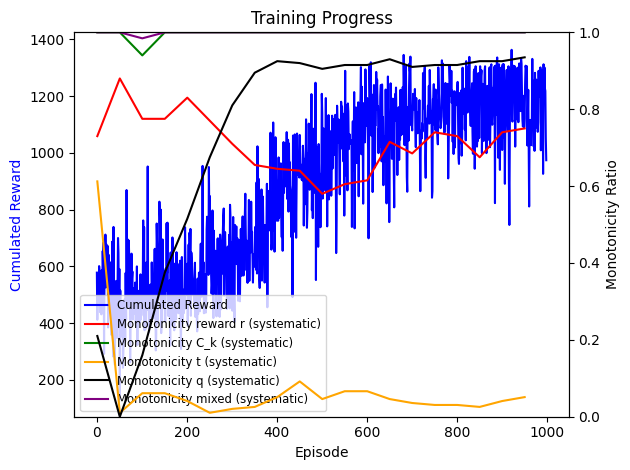

In [6]:
from training.plotting import plot_training_progress, plot_depth_epsilon

plot_training_progress(reward_history, monotonicity_violations)

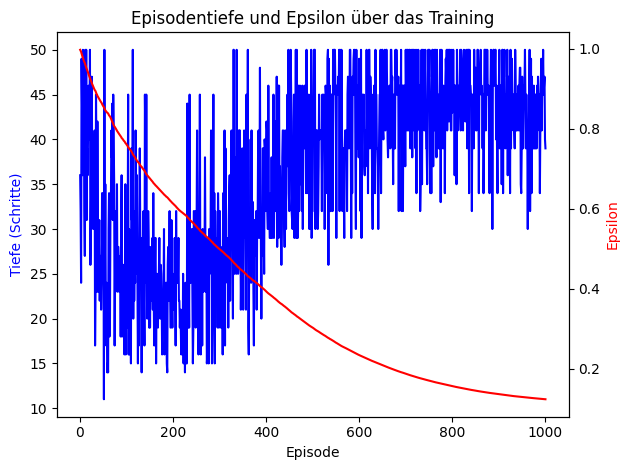

In [7]:
plot_depth_epsilon(depth_history)

In [8]:
import torch
net = agent.policy_net
net.eval()
obs, _ = env.reset()
print("Initial observation:", obs)
obs = [3,6,7,4,3,41,1,1,0,0]
modified_obs = obs.copy()
modified_obs[1:5] = [10,10,10,10]  
obs = torch.tensor(obs, dtype=torch.float32).unsqueeze(0)
modified_obs_t = torch.tensor(modified_obs, dtype=torch.float32).unsqueeze(0)
with torch.no_grad():
    q_values = net(obs)
    print("Q-values for initial state:", q_values)  
    q_values_modified = net(modified_obs_t)
    print("Q-values for modified state:", q_values_modified)

Initial observation: [ 1. 10. 10. 10. 10. 41.  1.  1.  0.  0.]
Q-values for initial state: tensor([[481.4167, 483.2550, 461.3754, 481.5370]])
Q-values for modified state: tensor([[824.8055, 828.2482, 811.6482, 824.7896]])


In [9]:
obs, _ = env.reset()
obs = torch.tensor(obs, dtype=torch.float32).unsqueeze(0)
done = False
cumulated_reward = 0.0

while not done:
                # 1. Aktion wählen
                action = net(obs)
                action = torch.argmax(action, dim=1).item()  # Greedy Aktion
                # 2. Umgebungsschritt
                next_obs, reward, terminated, truncated, _ = env.step(action)
                done = terminated or truncated

                obs = next_obs
                obs = torch.tensor(obs, dtype=torch.float32).unsqueeze(0)
                cumulated_reward += reward
print(cumulated_reward)

771.0


In [10]:
import torch

net = agent.policy_net
K = net.K

# Einen echten State holen
obs, _ = env.reset()
obs = torch.tensor(obs, dtype=torch.float32).unsqueeze(0)

with torch.no_grad():
    q_dqn   = net.dqn(obs)
    q_total = net(obs)
    bonus   = q_total - q_dqn

print(f"Q_dqn:   {q_dqn.numpy().flatten()}")
print(f"Bonus:   {bonus.numpy().flatten()[0]:.3f}")
print(f"Q_total: {q_total.numpy().flatten()}")

Q_dqn:   [792.61145 795.0351  780.9927  793.72797]
Bonus:   4.940
Q_total: [797.5512  799.9603  785.9058  798.63983]


Teste ob der Bonus einen wirklichen Einfluss hat

In [11]:
import torch

net = agent.policy_net
K = net.K

# Einen echten State holen
obs, _ = env.reset()
obs = torch.tensor(obs, dtype=torch.float32).unsqueeze(0)

with torch.no_grad():
    q_dqn   = net.dqn(obs)
    q_total = net(obs)
    bonus   = q_total - q_dqn

print(f"Q_dqn:   {q_dqn.numpy().flatten()}")
print(f"Bonus:   {bonus.numpy().flatten()[0]:.3f}")
print(f"Q_total: {q_total.numpy().flatten()}")

Q_dqn:   [792.61145 795.0351  780.9927  793.72797]
Bonus:   4.940
Q_total: [797.5512  799.9603  785.9058  798.63983]


Bonus erfüllt die Monotonieeigenschaft

In [12]:
for c_val in [0.0, 5.0, 10.0]:
    c_raw = torch.tensor([[c_val] * K], dtype=torch.float32)
    with torch.no_grad():
        c_cal = torch.cat(
            [cal(c_raw[:, k:k+1].double()).float()
             for k, cal in enumerate(net.c_calibrators)],
            dim=1,
        )
        bonus = net.c_lattice(c_cal.double()).float().item()
    print(f"C_k = {c_val:.0f}  →  Bonus = {bonus:.3f}")

RuntimeError: mat1 and mat2 shapes cannot be multiplied (1x16 and 32x1)